In [1]:
# PASO 1: Importamos las librerías necesarias

# Librerías con Pandas::
import pandas as pd # Para trabajar con DataFrames *
import numpy as np # Para trabajar con arrays y funciones matemáticas

# Librerías para visualización de datos:
import matplotlib.pyplot as plt # Para crear gráficos personalizados
import seaborn as sns # Para crear gráficos más atractivos y con menos código 

# Configuraciones:
import warnings # Para controlar las advertencias
warnings.filterwarnings('ignore', category = FutureWarning) # Para ignorar las advertencias de tipo FutureWarning
pd.set_option('display.max_columns', None) # Para mostrar todas las columnas del DataFrame *

In [2]:
# PASO 2: Cargamos el dataset ya limpio 

df_limpio = pd.read_csv("combinado_limpio.csv")

df_limpio.head()

,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
0,100018,2017,1,3,0,3,1521.0,152.0,0.0,0.0,Canada,Alberta,Edmonton,T9G 1W3,Female,Bachelor,92552.0,Married,Aurora,7919.20,Standard,2016,8,Desconocido,Desconocido
1,100102,2017,1,10,4,14,2030.0,203.0,0.0,0.0,Canada,Ontario,Toronto,M1R 4K3,Male,College,73447.0,Single,Nova,2887.74,Standard,2013,3,Desconocido,Desconocido
2,100140,2017,1,6,0,6,1200.0,120.0,0.0,0.0,Canada,British Columbia,Dawson Creek,U5I 4F1,Female,College,73447.0,Divorced,Nova,2838.07,Standard,2016,7,Desconocido,Desconocido
3,100214,2017,1,0,0,0,0.0,0.0,0.0,0.0,Canada,British Columbia,Vancouver,V5R 1W3,Male,Bachelor,63253.0,Married,Star,4170.57,Standard,2015,8,Desconocido,Desconocido
4,100272,2017,1,0,0,0,0.0,0.0,0.0,0.0,Canada,Ontario,Toronto,P1L 8X8,Female,Bachelor,91163.0,Divorced,Star,6622.05,Standard,2014,1,Desconocido,Desconocido


# PARTE 1: Análisis de variables numéricas

In [51]:
# PASO 1: Estadísticas descriptivas (media, mediana, moda, desviación estándar, etc.) de las variables numéricas relevantes

col_num_relevantes = ["Flights Booked", "Total Flights", "Distance", "Points Accumulated", "Points Redeemed", "Dollar Cost Points Redeemed", "Salary", "CLV"]

df_limpio[col_num_relevantes].describe().T

,count,mean,std,min,25%,50%,75%,max
Flights Booked,322755.0,4.010624,5.232702,0.00,0.00,0.00,8.00,21.00
Total Flights,322755.0,5.012582,6.526290,0.00,0.00,0.00,10.00,32.00
Distance,322754.0,1200.561734,1452.372707,0.00,0.00,0.00,2344.00,6293.00
Points Accumulated,322754.0,123.556356,149.306695,0.00,0.00,0.00,241.00,676.50
Points Redeemed,322754.0,29.577570,122.576698,0.00,0.00,0.00,0.00,876.00
Dollar Cost Points Redeemed,322754.0,2.394210,9.915802,0.00,0.00,0.00,0.00,71.00
Salary,322755.0,77832.616198,30055.211645,9081.00,63887.00,73447.00,82940.00,407228.00
CLV,322755.0,7997.776657,6879.274236,1898.01,3985.55,5776.34,8937.12,83325.38


- Descripción: Se eligieron estas columnas porque representan las variables numéricas más útiles para entender la actividad de vuelo ("Flights Booked", "Total Flights" y "Distance"), el uso del cliente ("Points Accumulated" y "Points Redeemed") ante los puntos y el valor económico del cliente ("Dollar Cost Points Redeemed", "Salary" y "CLV")

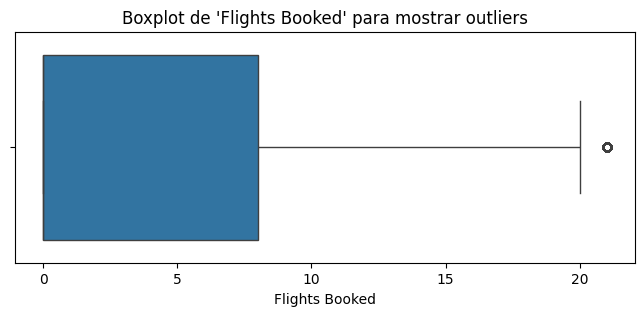

----------------------------------------------------------------------------------------------------


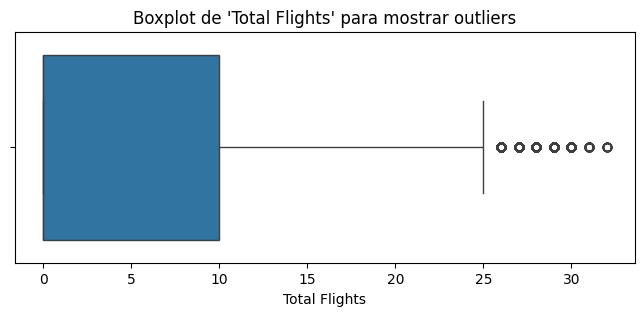

----------------------------------------------------------------------------------------------------


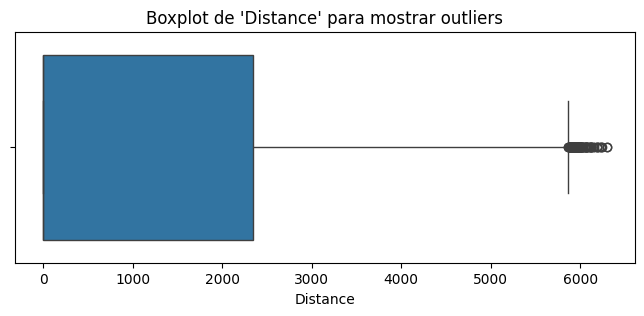

----------------------------------------------------------------------------------------------------


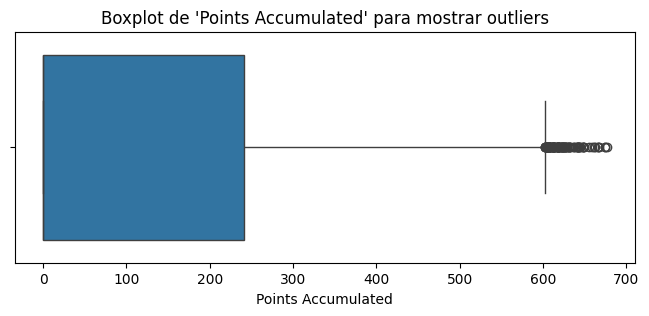

----------------------------------------------------------------------------------------------------


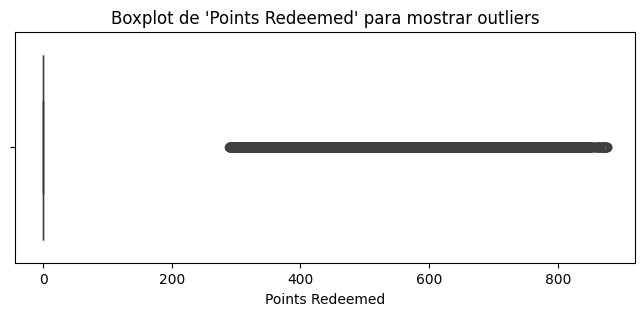

----------------------------------------------------------------------------------------------------


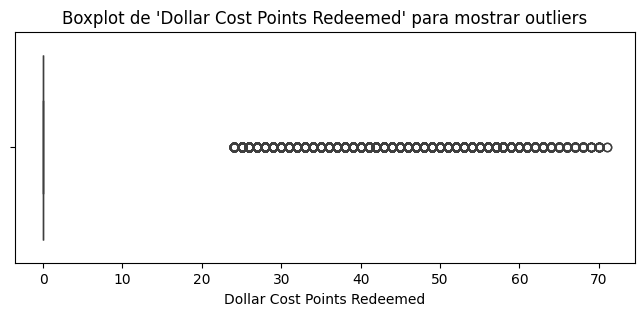

----------------------------------------------------------------------------------------------------


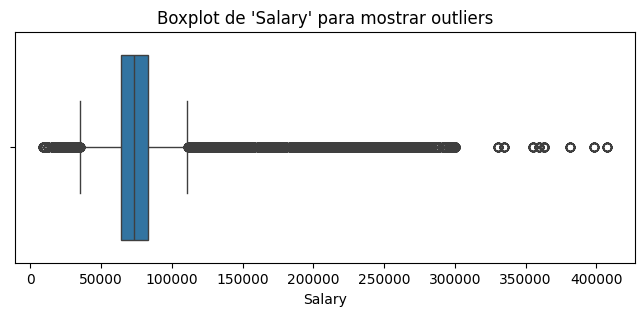

----------------------------------------------------------------------------------------------------


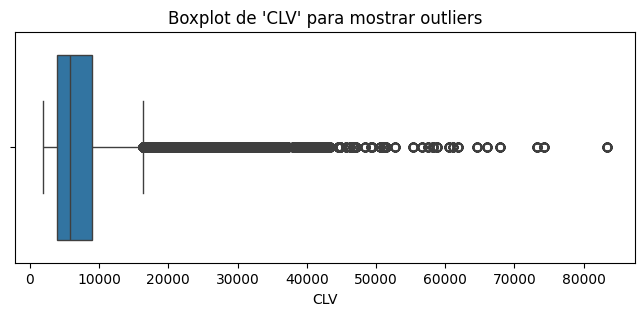

----------------------------------------------------------------------------------------------------


In [52]:
# PASO 2: Identificación de valores atípicos en las variables numéricas (outliers)

for col in col_num_relevantes: 
    plt.figure(figsize=(8, 3)) # Para ajustar el tamaño de la gráfica
    sns.boxplot(data=df_limpio, x=df_limpio[col]) # Para mostrar la distribución y valores atípicos de una variable numérica
    plt.title(f"Boxplot de '{col}' para mostrar outliers")
    plt.show()
    print("-"*100)

- Descripción: Los boxplots muestran la presencia de valores atípicos en TODAS las variables numéricas seleccionadas. En general, la mayoría de los datos se concentra en valores bajos, mientras que una parte reducida de las observaciones alcanza valores mucho más altos. Este patrón se aprecia especialmente en variables como "Distance", "Points Accumulated", "Salary" y "CLV"

count    322754.00
mean       1200.56
std        1452.37
min           0.00
25%           0.00
50%           0.00
75%        2344.00
max        6293.00
Name: Distance, dtype: float64
--------------------------------------------------


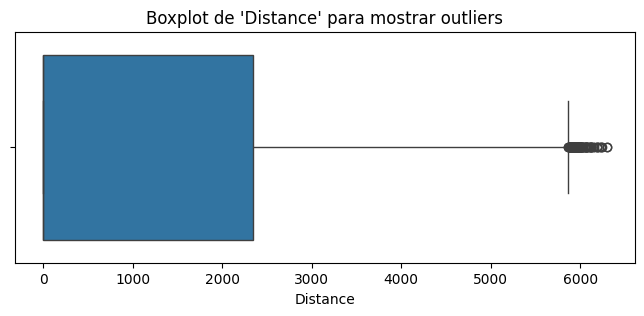

In [53]:
print(df_limpio["Distance"].describe().round(2))

print("-"*50)

plt.figure(figsize=(8, 3))
sns.boxplot(data=df_limpio, x="Distance")
plt.title(f"Boxplot de 'Distance' para mostrar outliers")
plt.show()

- Ejemplo con "Distance": 

    - En los datos estadísticos la mediana está en 0 y el valor máximo supera los 6200
    - En el boxplot se ven muchos puntos muy a la derecha del resto, y eso significa que hay ditancias mucho más altas que la mayoría

In [54]:
# PASO 3: Análisis de correlación entre variables numéricas

correlacion = df_limpio[col_num_relevantes].corr(method="spearman", numeric_only=True)

correlacion

,Flights Booked,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed,Salary,CLV
Flights Booked,1.000000,0.988851,0.907725,0.905056,0.229896,0.229898,0.011269,-0.000030
Total Flights,0.988851,1.000000,0.913131,0.910063,0.269094,0.269095,0.010919,-0.000215
Distance,0.907725,0.913131,1.000000,0.997704,0.283310,0.283309,0.012160,-0.001157
Points Accumulated,0.905056,0.910063,0.997704,1.000000,0.281504,0.281503,0.012232,0.002567
Points Redeemed,0.229896,0.269094,0.283310,0.281504,1.000000,0.999999,0.001865,0.001752
Dollar Cost Points Redeemed,0.229898,0.269095,0.283309,0.281503,0.999999,1.000000,0.001864,0.001756
Salary,0.011269,0.010919,0.012160,0.012232,0.001865,0.001864,1.000000,-0.009483
CLV,-0.000030,-0.000215,-0.001157,0.002567,0.001752,0.001756,-0.009483,1.000000


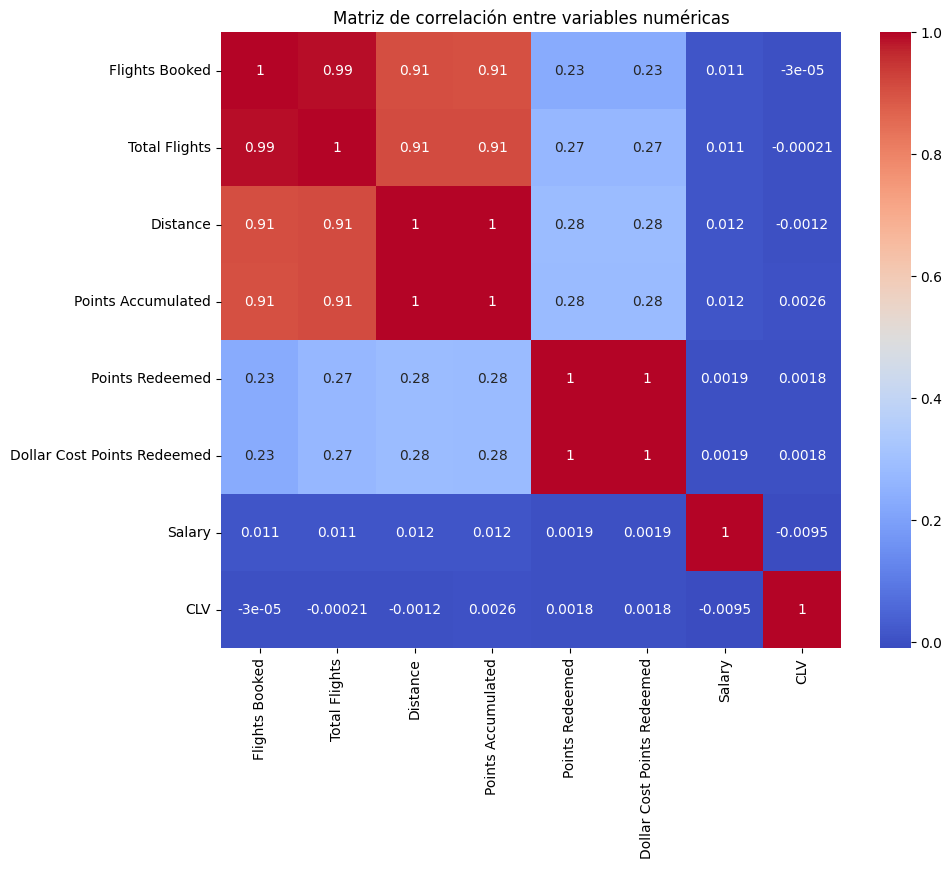

In [55]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlacion, annot=True, cmap="coolwarm") # Para visualizar la relación entre variables numéricas mediante colores
plt.title("Matriz de correlación entre variables numéricas")
plt.show()

- Descripción: La matriz de correlación muestra relaciones positivas fuertes entre "Flights Booked" con "Total Flights" - 0.96%, "Points Accumulated" con "Distance" - 0.99%, y "Dollar Cost Points Redeemed" con "Points Redeemed" - 1%. En cambio, "Salary" y "CLV" presentan correlaciones débiles con el resto de variables

-------

# PARTE 2: Análisis de variables categóricas

In [50]:
# PASO 4: Distribución de frecuencias de las variables categóricas relevantes

col_cat_relevantes = ["Country", "City", "Gender", "Education", "Marital Status", "Loyalty Card", "Enrollment Type"]

df_limpio[col_cat_relevantes].describe(include="str").T

,count,unique,top,freq
Country,322755,1,Canada,322755
City,322755,29,Toronto,64578
Gender,322755,2,Female,162187
Education,322755,5,Bachelor,201846
Marital Status,322755,3,Married,187851
Loyalty Card,322755,3,Star,147008
Enrollment Type,322755,2,Standard,303964


- Descripción: Se eligieron estas columnas porque representan las variables categóricas más útiles para describir el perfil general ("Gender", "Education" y "Marital Status") de los clientes y su localización ("Country" y "City"), y su relación con el programa de fidelización ("Loyalty Card" y "Enrollment Typ")